In [151]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi']= 300
from scipy.special import roots_legendre

In [152]:
# set cross section
LX = 100 #width
NEL = 100 #number of elements

dx = np.ones(NEL) * LX / NEL
NEL2COORD = np.cumsum(dx) - dx / 2

SigT = np.ones(NEL) * 0.0181
Qm = np.ones(NEL) / (2 * np.pi)

In [153]:
# set quadrature 
NQ = 4
dtheta = 2 * np.pi / NQ
theta = (np.arange(NQ) + 0.5) * dtheta
w = np.full(NQ, dtheta)
mu = np.cos(theta)


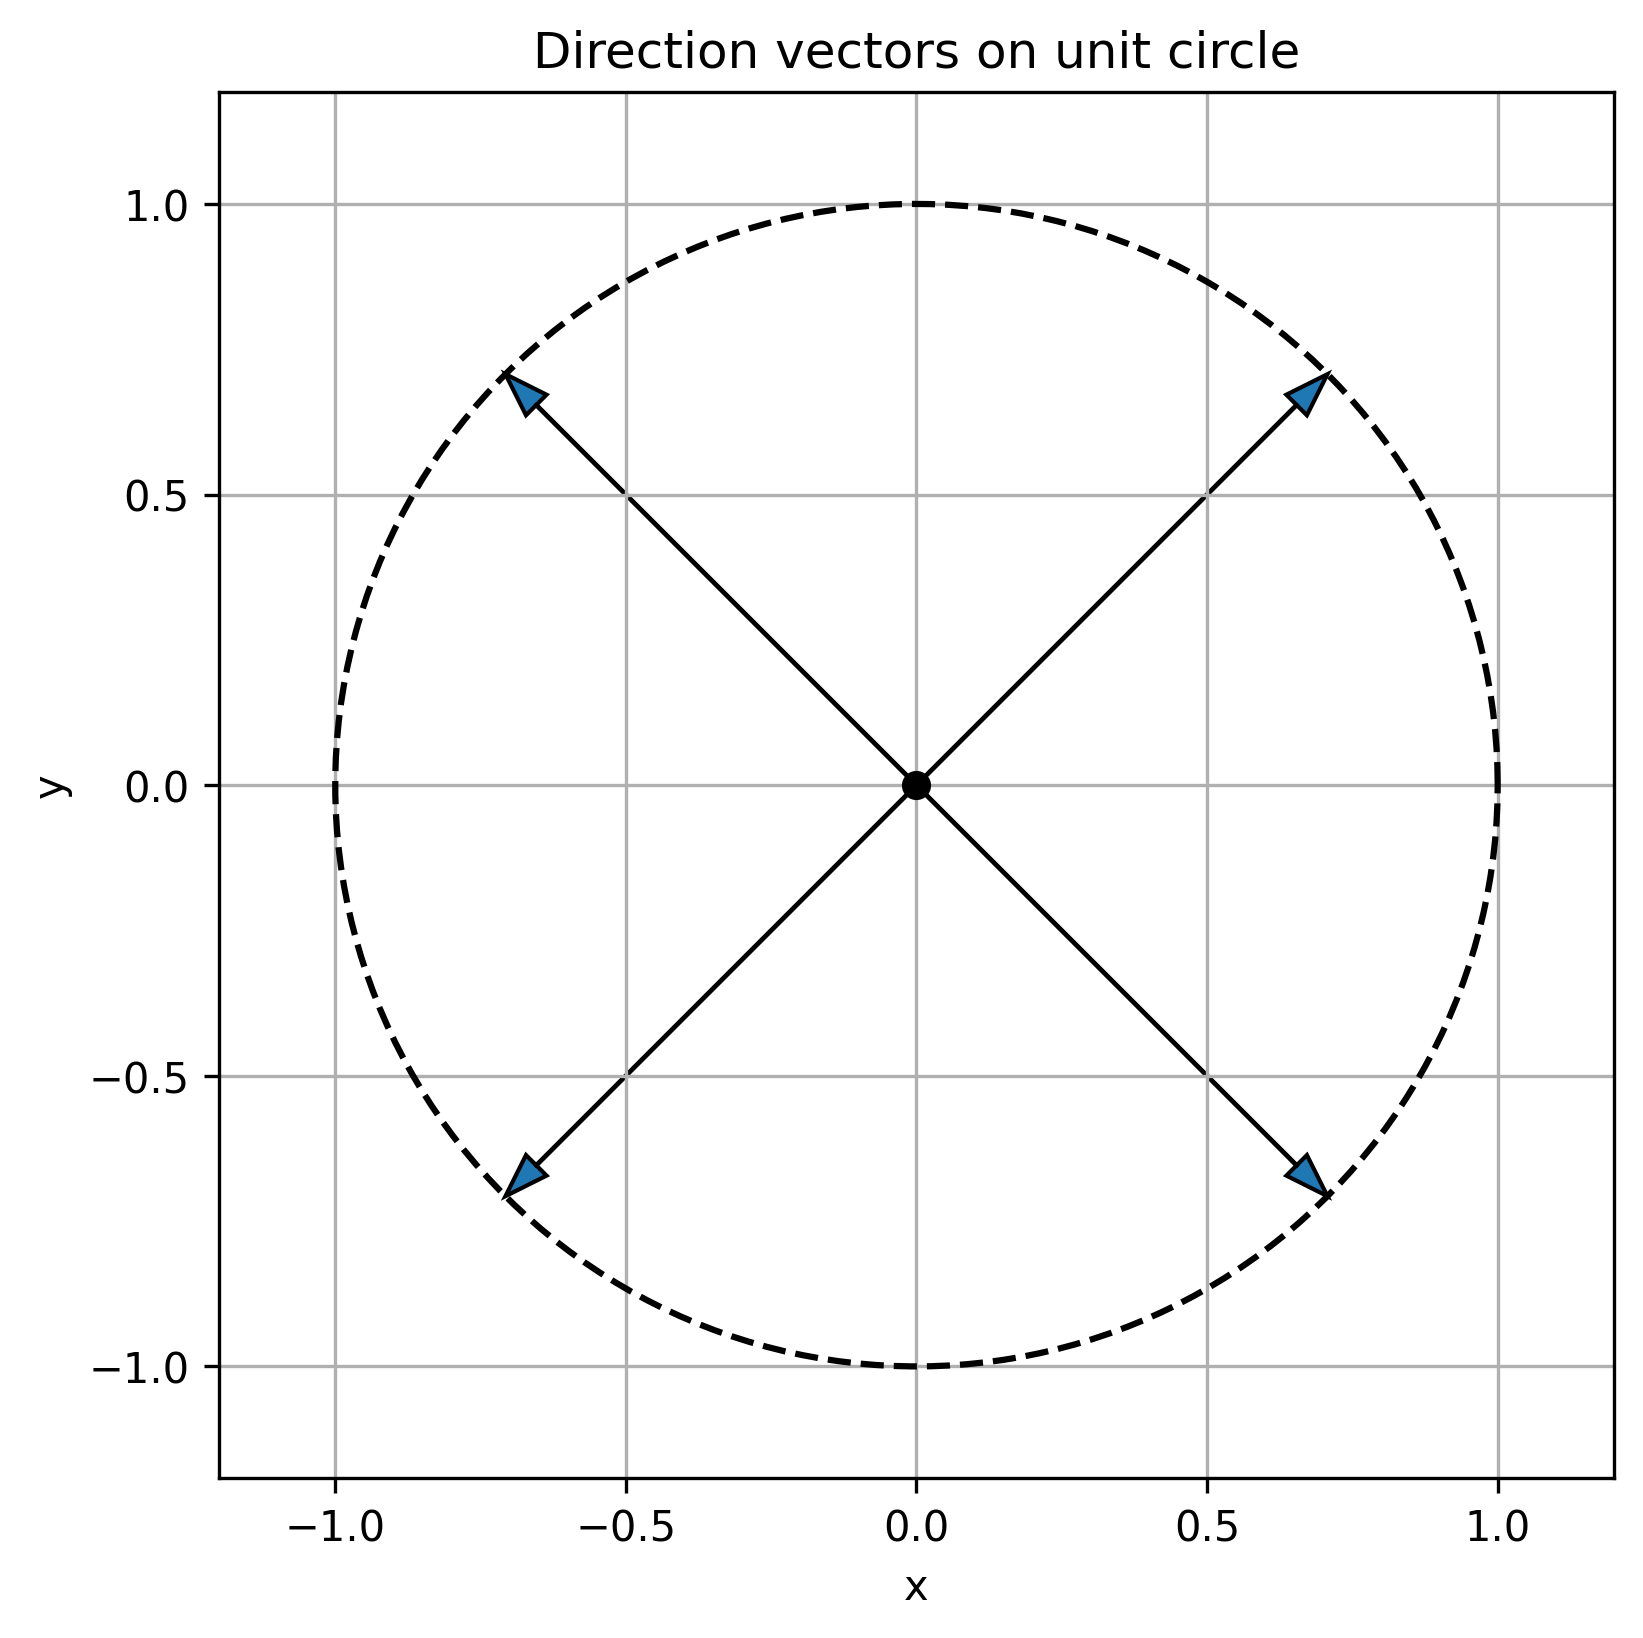

In [154]:
# 単位円上の座標
x = np.cos(theta)
y = np.sin(theta)

# プロット
plt.figure(figsize=(6,6))

# 単位円
t = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(t), np.sin(t), 'k--', label="Unit circle")

# ベクトル（原点 → 円周）
for i in range(NQ):
    plt.arrow(0, 0, x[i], y[i],
              head_width=0.05,
              length_includes_head=True)

# 原点
plt.plot(0, 0, 'ko')

# 表示調整
plt.axis("equal")
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Direction vectors on unit circle")
plt.show()

In [155]:
def WDDTransportSweep(SigT, Qm, dx, w, mu):
    NX = len(dx)
    NM = len(w)
    
    psis = np.zeros((NM, NX + 1))
    psi = np.zeros((NM, NX))
    phi = np.zeros(NX)
    
    for m in range(NM):
        if mu[m] > 0.0:
            startX = 0
            endX  = NX
            signX = 1
            delta_iin = 0
            delta_iout = 1
        else:
            startX = NX - 1
            endX  = -1
            signX = -1
            delta_iin = 1
            delta_iout = 0
            
        for i in range(startX, endX, signX):
            iin = i + delta_iin
            iout = i + delta_iout
            a = 1/2
            psis[m, iout] = (Qm[i] * dx[i]+ (np.abs(mu[m]) - (1 - a) * SigT[i]) * psis[m, iin]) / (np.abs(mu[m]) + a * SigT[i] * dx[i]) 
            psi[m, i] = a*psis[m, iout] + (1-a)*psis[m, iin]
            
            phi[i] += psi[m, i] * w[m]

    return phi, psi

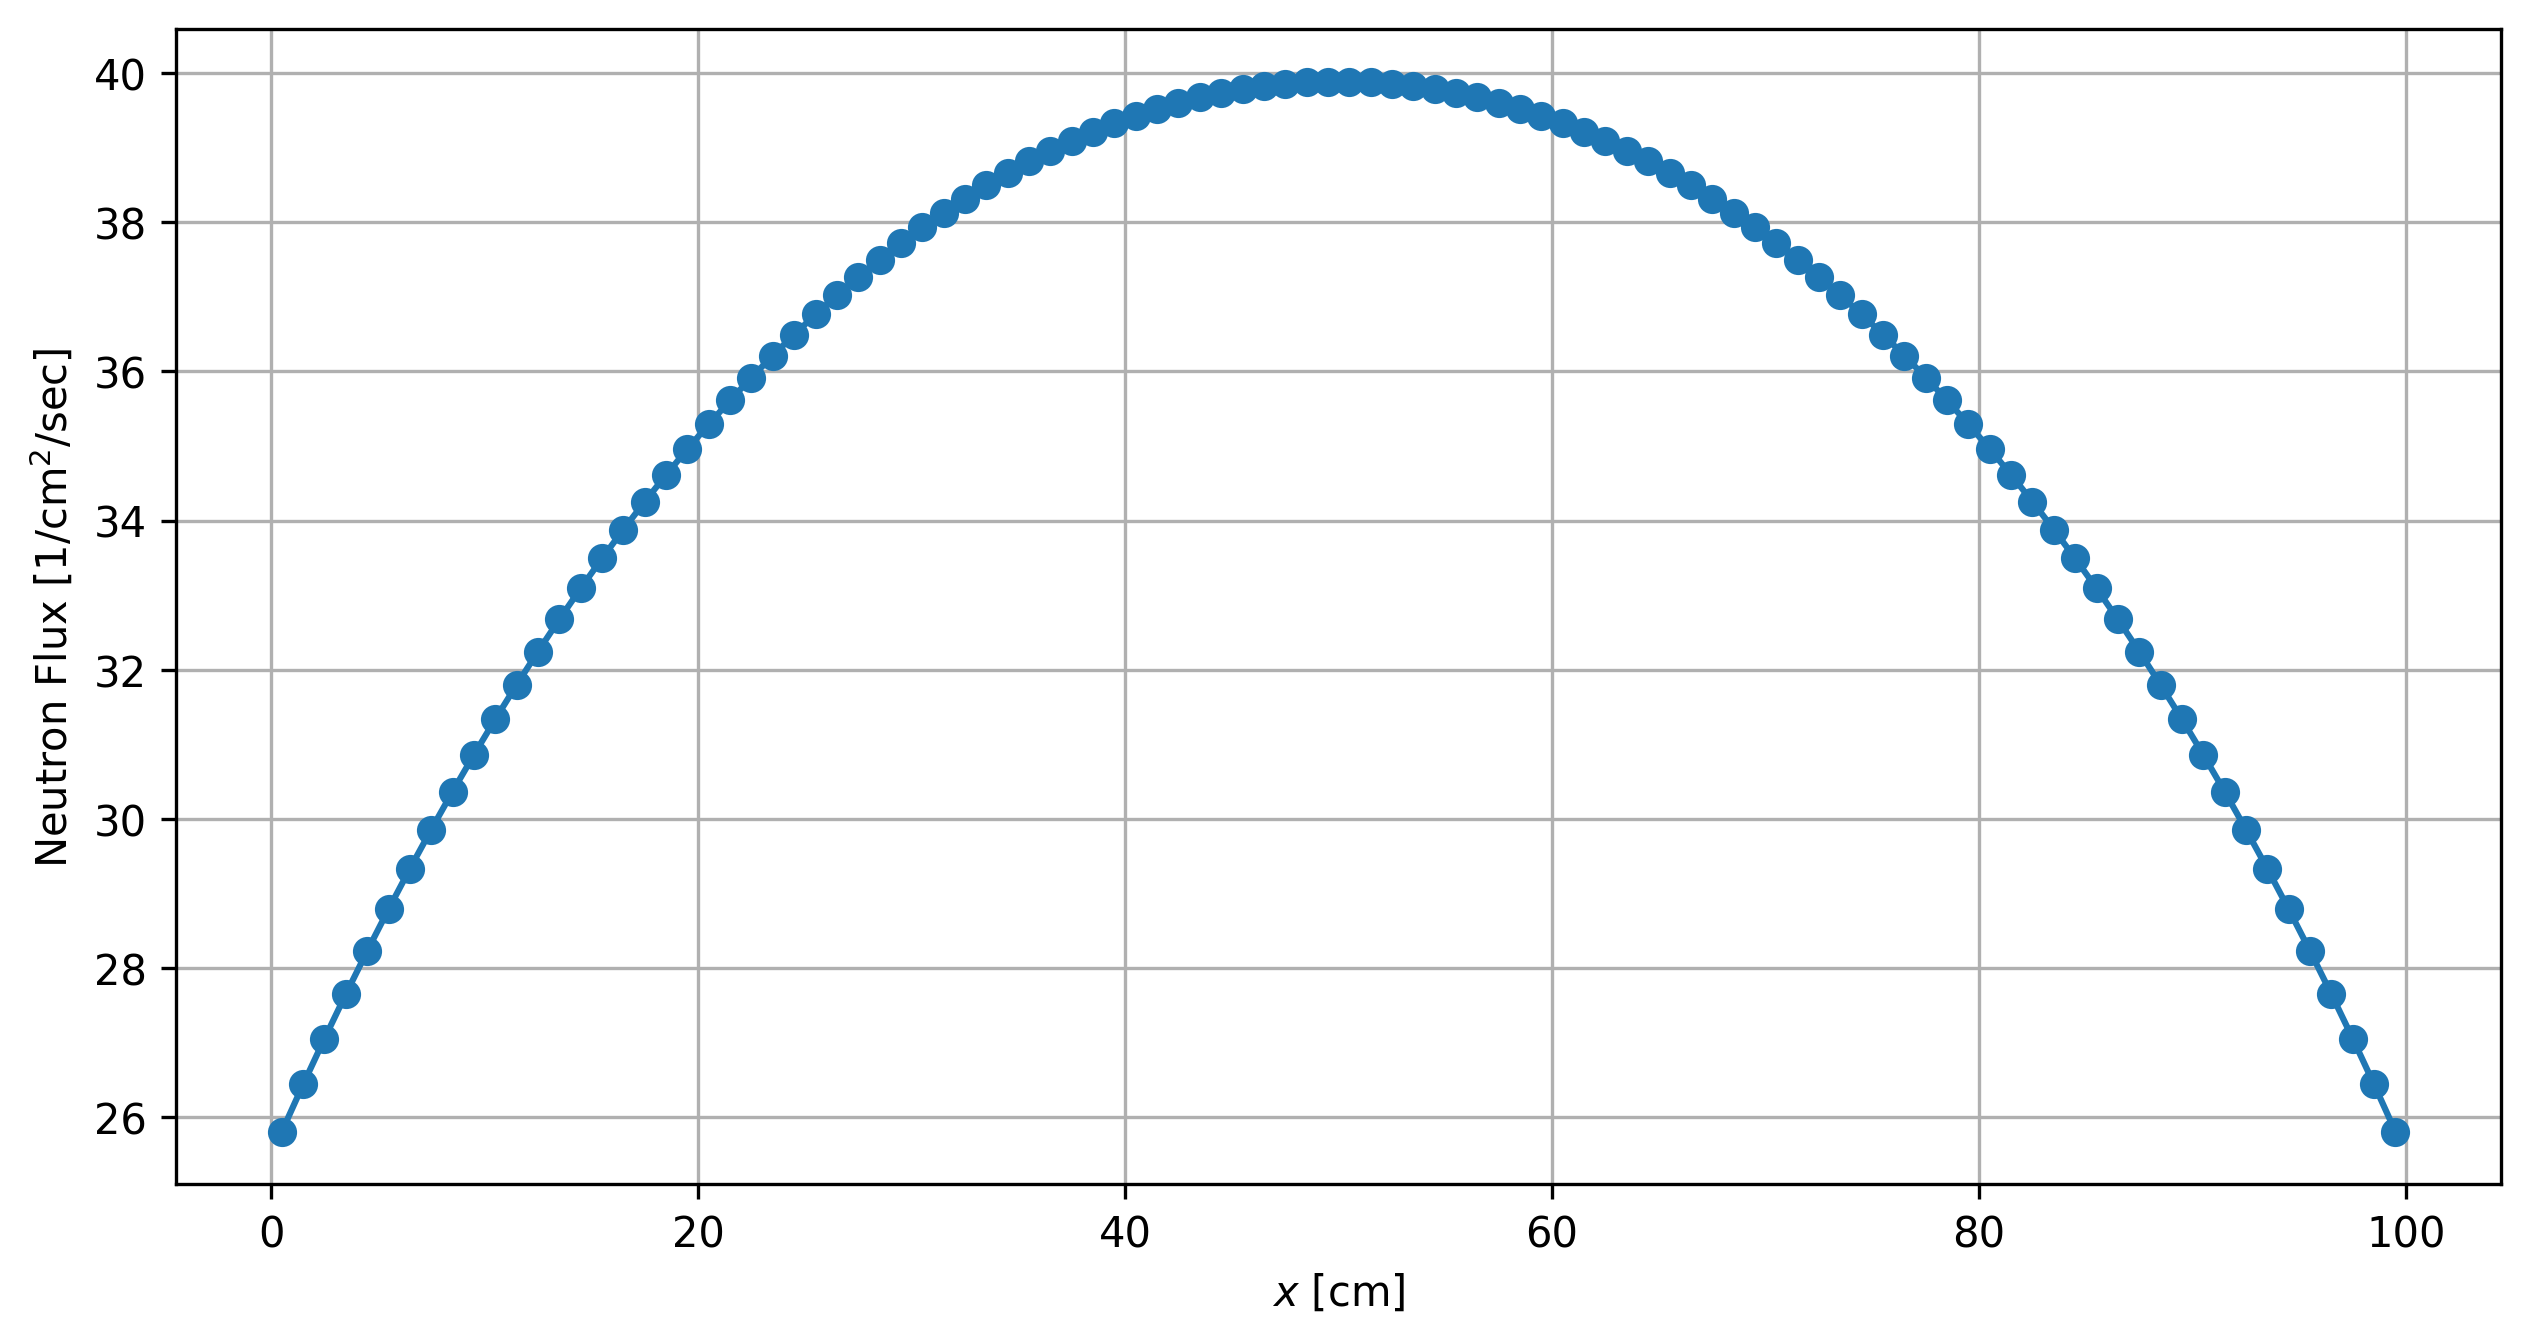

In [156]:
import numpy as np
import matplotlib.pyplot as plt

# 要素中心座標
NEL2COORD = np.cumsum(dx) - dx / 2

# 輸送計算
Phi, Psi = WDDTransportSweep(SigT, Qm, dx, w, mu)

# プロット
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel(r'$x$ [cm]')
ax.set_ylabel(r'Neutron Flux [1/cm$^2$/sec]')
ax.plot(NEL2COORD, Phi, label='WDD', marker='o')
plt.grid(True)

plt.show()

SyntaxError: keyword argument repeated: label (2926886692.py, line 8)

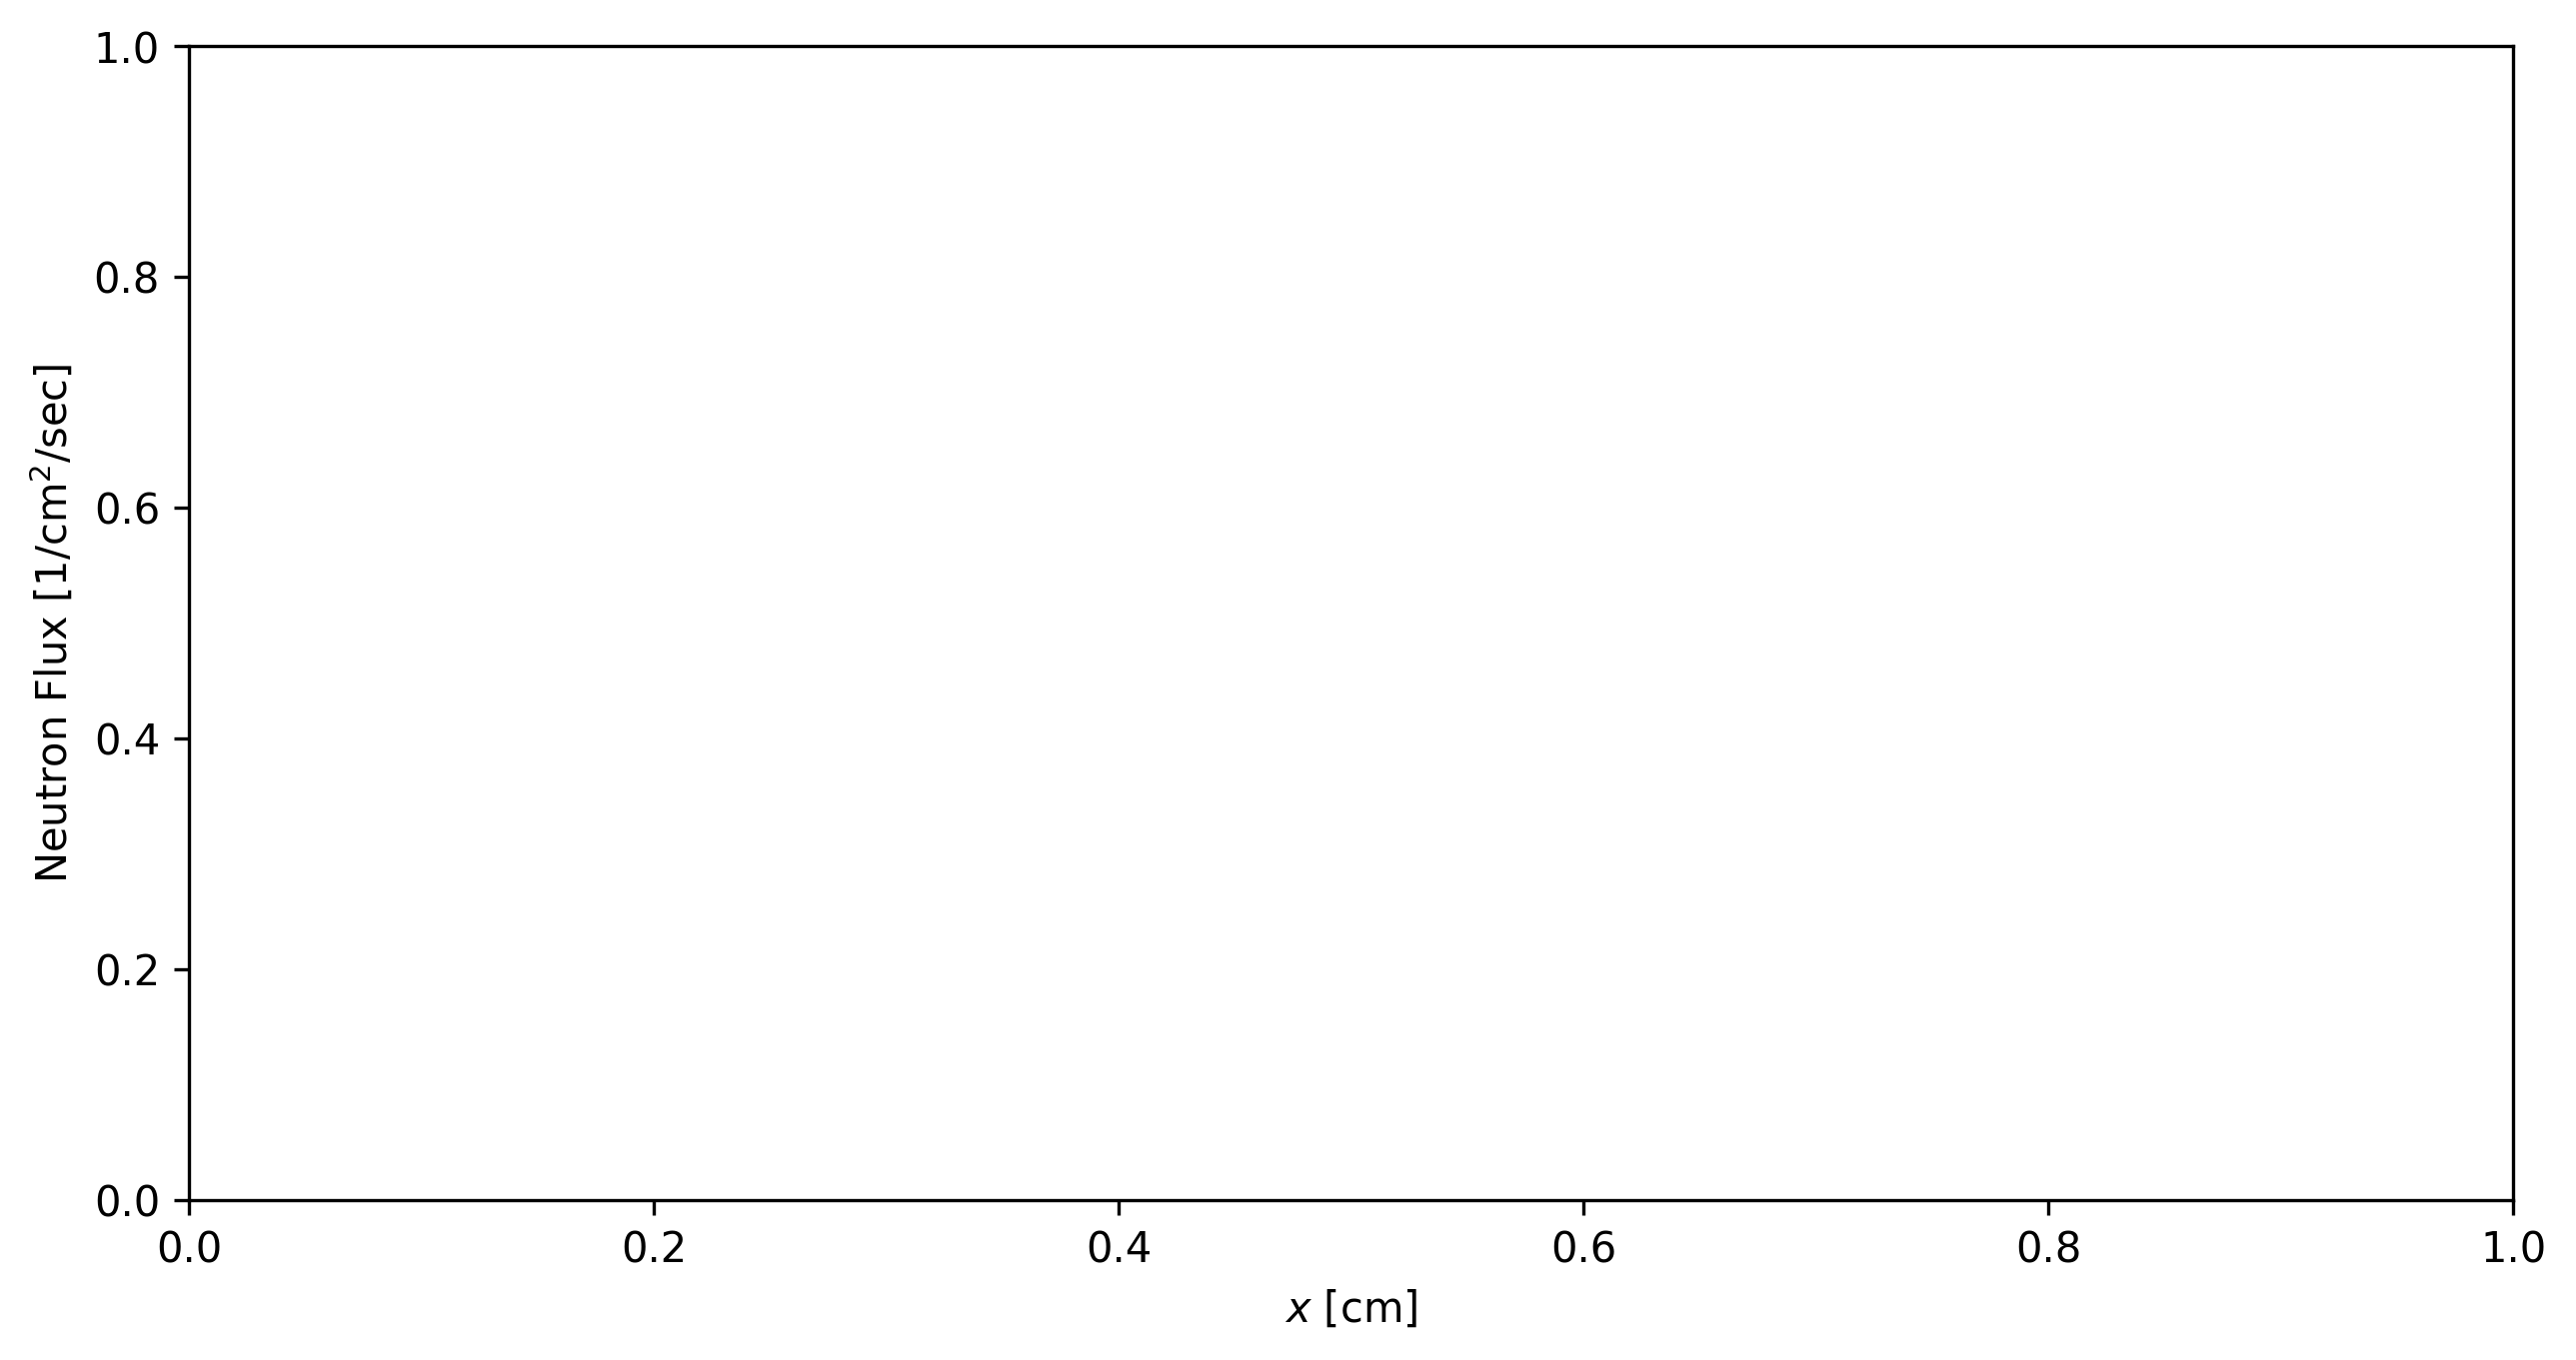

In [ ]:
import analytical1D
Phi_ana, Psi_ana, XX = analytical1D.analytical_sol_1D(SigT, Qm, dx, mu, w, 1, True)

# プロット
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel(r'$x$ [cm]')
ax.set_ylabel(r'Neutron Flux [1/cm$^2$/sec]')
ax.plot(NEL2COORD, Phi, label='WDD', marker='o')
ax.plot(XX, Phi_ana, label='Analytical', marker='x')
ax.grid(True)
ax.legend()
plt.show()